# Application Project #3
<h2> Regime Change Detection in Apple Inc. (AAPL) Daily Returns</h2>
<strong>Prepared by:</strong> Adrian Kajongwe
<p>
<strong>Registration Number:</strong> R2420849
</p>
<strong>Course:</strong> Applied Time Series Analysis

**<i>Model: Detecting a Regime Change using Hidden Markov Models (HMM) and Markov-Switching Regression**</i>

---

## 1. Install & Import Libraries

In [3]:
# Install required packages (uncomment if running in Colab)
# !pip install yfinance statsmodels hmmlearn matplotlib seaborn pandas numpy scipy

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Data download
import yfinance as yf

# Statistical models
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

# Install hmmlearn if not already installed
!pip install hmmlearn

# Hidden Markov Model
from hmmlearn.hmm import GaussianHMM

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

# Statistics
from scipy import stats

# Plot styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('deep')

print('All libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.2 MB/s eta 0:00:00
All libraries loaded successfully.


---
## 2. Definition — The Markov-Switching Model

### Technical Definition

A **Markov-Switching (MS) model** (also called a Hamilton regime-switching model) assumes the data-generating process switches between $K$ discrete latent states (regimes). The unobserved state $s_t \in \{1, 2, \ldots, K\}$ evolves as a **first-order Markov chain** with transition probability matrix:

$$P = \begin{bmatrix} p_{11} & p_{12} \\ p_{21} & p_{22} \end{bmatrix}, \quad p_{ij} = \Pr(s_t = j \mid s_{t-1} = i), \quad \sum_j p_{ij} = 1$$

Given state $s_t$, the observed time series $y_t$ follows a **regime-dependent autoregressive process**:

$$y_t = \mu_{s_t} + \sum_{k=1}^{p} \phi_{k, s_t}\, y_{t-k} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^2_{s_t})$$

where:
- $\mu_{s_t}$ is the regime-specific intercept (mean return)
- $\phi_{k, s_t}$ is the $k$-th autoregressive coefficient in regime $s_t$
- $\sigma^2_{s_t}$ is the regime-specific variance
- $p_{ij}$ is the probability of transitioning from regime $i$ to regime $j$
- The **unconditional (ergodic) probability** of being in regime $j$ is $\pi_j = \frac{1 - p_{ii}}{2 - p_{11} - p_{22}}$
- The **expected duration** of regime $i$ is $D_i = \frac{1}{1 - p_{ii}}$

### Description

A Markov-switching model captures structural breaks in financial time series by allowing the mean, variance, and/or autocorrelation structure of returns to differ across hidden market regimes (e.g., bull vs. bear markets). The latent state transitions are governed by a Markov chain, meaning the probability of entering a new regime depends only on the current regime—not on the history of past regimes.

---

## 3. Data Import & Description

**Dataset:** Apple Inc. (AAPL) daily adjusted closing prices  
**Source:** Yahoo Finance via `yfinance`  
**Frequency:** Daily  
**Period:** January 2010 – December 2024  
**Units:** USD (Adjusted Close Price); Log-returns are dimensionless (%)  

**Rationale for this dataset:**  
AAPL is a high-volume, highly-liquid equity that has experienced multiple macroeconomically distinct periods between 2010 and 2024 — including the post-GFC bull run, the 2020 COVID crash, and the 2022 rate-hike bear market. These structural breaks in mean return and volatility make AAPL daily returns an ideal test case for regime-switching models. Prior ADF testing confirms the price series is non-stationary (I(1)), while log-returns are stationary and exhibit volatility clustering — consistent with regime switching.

In [4]:
# ── Step 1: Download AAPL daily data from Yahoo Finance ──────────────────────
ticker = 'AAPL'
start_date = '2010-01-01'
end_date   = '2024-12-31'

raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
raw.index = pd.to_datetime(raw.index)

print(f'Downloaded {len(raw)} trading days of {ticker} data.')
print(f'Date range: {raw.index[0].date()} to {raw.index[-1].date()}')
raw[['Close']].tail()

[*********************100%***********************]  1 of 1 completed

Downloaded 3773 trading days of AAPL data.
Date range: 2010-01-04 to 2024-12-30


Price,Close
Ticker,AAPL
Date,
2024-12-23,253.883118
2024-12-24,256.797241
2024-12-26,257.612701
2024-12-27,254.201370
2024-12-30,250.829788


In [5]:
# ── Step 2: Compute daily log-returns ─────────────────────────────────────────
prices = raw['Close'].dropna().squeeze() # Ensure prices is a Series
log_returns = np.log(prices / prices.shift(1)).dropna().squeeze() # Ensure log_returns is a Series
log_returns.name = 'Log_Return'

df = pd.DataFrame({'Price': prices, 'Log_Return': log_returns}).dropna()

print('Summary statistics of daily log-returns:')
print(df['Log_Return'].describe())
print(f'\nSkewness : {df["Log_Return"].skew():.4f}')
print(f'Kurtosis : {df["Log_Return"].kurtosis():.4f}')

Summary statistics of daily log-returns:
count    3772.000000
mean        0.000972
std         0.017561
min        -0.137708
25%        -0.007428
50%         0.001004
75%         0.010303
max         0.113158
Name: Log_Return, dtype: float64

Skewness : -0.2353
Kurtosis : 5.4532


---
## 4. Diagram — Exploratory Plots

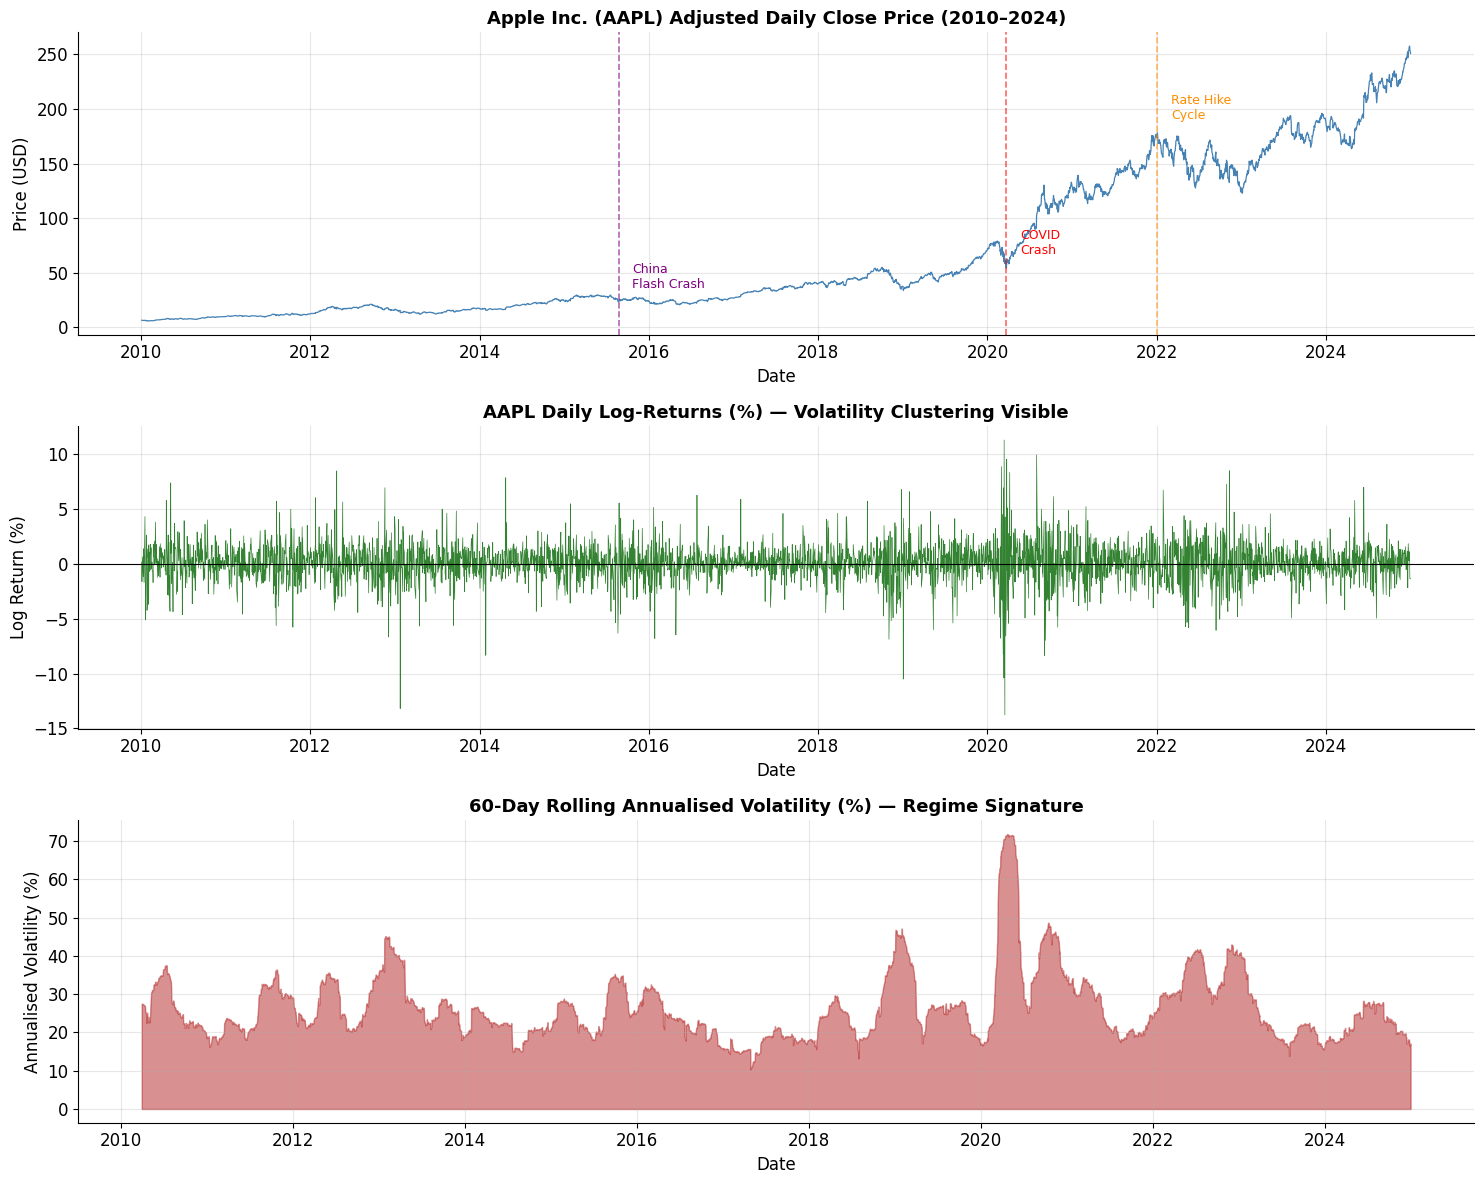

Figure 1 saved.


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Price series
axes[0].plot(df.index, df['Price'], color='steelblue', linewidth=0.9)
axes[0].set_title('Apple Inc. (AAPL) Adjusted Daily Close Price (2010–2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].set_xlabel('Date')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(alpha=0.3)

# Annotate key events
events = {
    '2020-03-23': ('COVID\nCrash', 'red'),
    '2022-01-03': ('Rate Hike\nCycle', 'darkorange'),
    '2015-08-24': ('China\nFlash Crash', 'purple'),
}
for date_str, (label, color) in events.items():
    date = pd.Timestamp(date_str)
    if date in df.index:
        y_val = df.loc[date, 'Price']
        axes[0].axvline(date, color=color, linestyle='--', alpha=0.6, linewidth=1.2)
        axes[0].annotate(label, xy=(date, y_val), xytext=(10, 10),
                         textcoords='offset points', fontsize=9, color=color)

# Plot 2: Log-returns
axes[1].plot(df.index, df['Log_Return'] * 100, color='darkgreen', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('AAPL Daily Log-Returns (%) — Volatility Clustering Visible', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log Return (%)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.3)

# Plot 3: Rolling volatility (60-day)
roll_vol = df['Log_Return'].rolling(60).std() * np.sqrt(252) * 100
axes[2].fill_between(df.index, roll_vol, alpha=0.5, color='firebrick')
axes[2].set_title('60-Day Rolling Annualised Volatility (%) — Regime Signature', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Annualised Volatility (%)')
axes[2].set_xlabel('Date')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_exploratory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

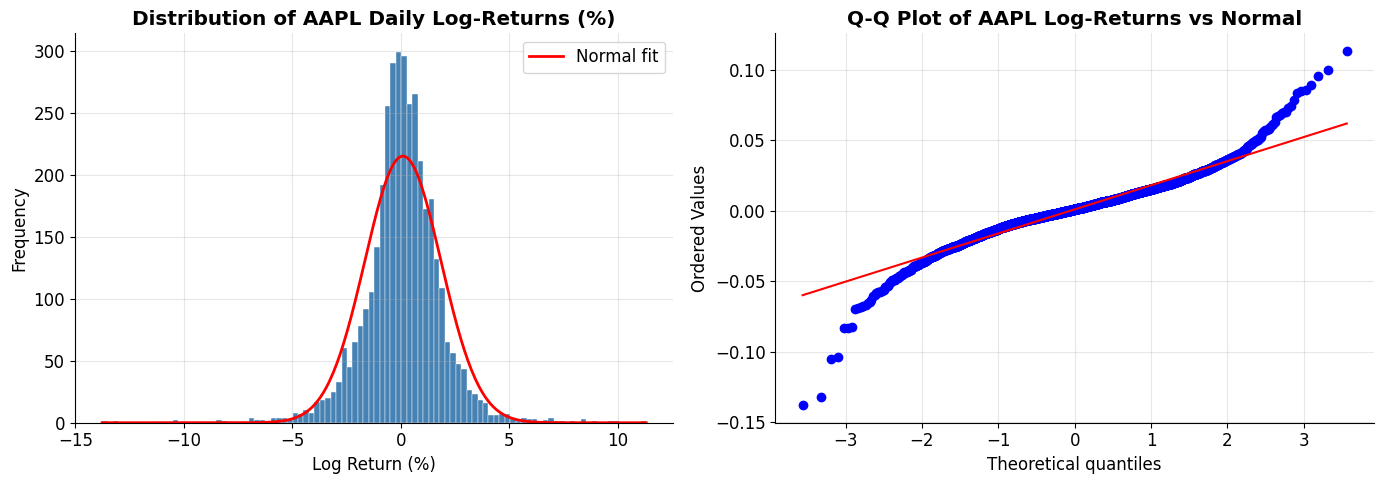

Figure 2 saved.


In [7]:
# Return distribution & QQ-plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Log_Return'] * 100, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
x = np.linspace(df['Log_Return'].min() * 100, df['Log_Return'].max() * 100, 300)
mu, sigma = df['Log_Return'].mean() * 100, df['Log_Return'].std() * 100
axes[0].plot(x, stats.norm.pdf(x, mu, sigma) * len(df) * (df['Log_Return'].max() - df['Log_Return'].min()) * 100 / 100,
             'r-', linewidth=2, label='Normal fit')
axes[0].set_title('Distribution of AAPL Daily Log-Returns (%)', fontweight='bold')
axes[0].set_xlabel('Log Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

stats.probplot(df['Log_Return'], plot=axes[1])
axes[1].set_title('Q-Q Plot of AAPL Log-Returns vs Normal', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## 5. Demonstration — Stationarity Test & Model Estimation

### 5a. ADF Unit Root Test on Price Level and Log-Returns

In [8]:
def adf_report(series, series_name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n── ADF Test: {series_name} ──')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.6f}')
    print(f'  Lags Used     : {result[2]}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    conclusion = 'STATIONARY (reject H0)' if result[1] < 0.05 else 'NON-STATIONARY (fail to reject H0)'
    print(f'  Conclusion: {conclusion}')

adf_report(df['Price'], 'AAPL Price Level')
adf_report(df['Log_Return'], 'AAPL Log-Returns')


── ADF Test: AAPL Price Level ──
  ADF Statistic : 1.7638
  p-value       : 0.998274
  Lags Used     : 18
  Critical Values:
    1%: -3.4321
    5%: -2.8623
    10%: -2.5672
  Conclusion: NON-STATIONARY (fail to reject H0)

── ADF Test: AAPL Log-Returns ──
  ADF Statistic : -20.3246
  p-value       : 0.000000
  Lags Used     : 8
  Critical Values:
    1%: -3.4321
    5%: -2.8623
    10%: -2.5672
  Conclusion: STATIONARY (reject H0)


### 5b. Markov-Switching Autoregression (MS-AR) — 2-Regime Model

We estimate Hamilton's (1989) Markov-switching model with **2 regimes** using Maximum Likelihood Estimation (MLE). We allow both the **mean** and **variance** to switch across regimes.

In [9]:
# ── Markov-Switching Autoregression (k=2, AR order=1) ────────────────────────
y = df['Log_Return'].values * 100  # scale to percent for numerical stability
y_series = pd.Series(y, index=df.index)

ms_model = MarkovAutoregression(
    y_series,
    k_regimes=2,
    order=1,           # AR(1) within each regime
    switching_ar=True, # AR coefficient also switches
    switching_variance=True
)

ms_result = ms_model.fit(search_reps=10, search_iter=50, disp=False)
print(ms_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                 3771
Model:             MarkovAutoregression   Log Likelihood               -7089.819
Date:                  Fri, 08 May 2026   AIC                          14195.638
Time:                          14:31:42   BIC                          14245.518
Sample:                               0   HQIC                         14213.372
                                 - 3771                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1655      0.027      6.165      0.000       0.113       0.218
sigma2         1.3895      0.068    

### 5c. Parameter Interpretation

In [10]:
params = ms_result.params
print('=' * 60)
print('         MARKOV-SWITCHING AR(1) — PARAMETER INTERPRETATION')
print('=' * 60)

# Transition probabilities
p00 = ms_result.params['p[0->0]'] # Probability of staying in Regime 0
p10 = ms_result.params['p[1->0]'] # Probability of transitioning from Regime 1 to Regime 0

p01 = 1 - p00 # Probability of transitioning from Regime 0 to Regime 1
p11 = 1 - p10 # Probability of staying in Regime 1

print(f'\n── Transition Probability Matrix ──')
print(f'  P(Regime 0 → Regime 0): p00 = {p00:.4f}')
print(f'  P(Regime 0 → Regime 1): p01 = {p01:.4f}')
print(f'  P(Regime 1 → Regime 0): p10 = {p10:.4f}')
print(f'  P(Regime 1 → Regime 1): p11 = {p11:.4f}')

dur0 = 1 / (1 - p00)
dur1 = 1 / (1 - p11)
print(f'\n── Expected Duration per Regime ──')
print(f'  Regime 0 expected duration: {dur0:.1f} trading days ({dur0/21:.1f} months)')
print(f'  Regime 1 expected duration: {dur1:.1f} trading days ({dur1/21:.1f} months)')

# Identify which regime has higher volatility
sig_keys = [k for k in params.index if 'sigma' in k.lower() or 'var' in k.lower()]
print(f'\n── Available sigma/variance keys: {sig_keys}')

const_keys = [k for k in params.index if 'const' in k.lower()]
print(f'\n── Intercept (mean) keys: {const_keys}')
for ck in const_keys:
    print(f'  {ck}: {params[ck]:.6f} % per day')

         MARKOV-SWITCHING AR(1) — PARAMETER INTERPRETATION

── Transition Probability Matrix ──
  P(Regime 0 → Regime 0): p00 = 0.9582
  P(Regime 0 → Regime 1): p01 = 0.0418
  P(Regime 1 → Regime 0): p10 = 0.1234
  P(Regime 1 → Regime 1): p11 = 0.8766

── Expected Duration per Regime ──
  Regime 0 expected duration: 23.9 trading days (1.1 months)
  Regime 1 expected duration: 8.1 trading days (0.4 months)

── Available sigma/variance keys: ['sigma2[0]', 'sigma2[1]']

── Intercept (mean) keys: ['const[0]', 'const[1]']
  const[0]: 0.165545 % per day
  const[1]: -0.116439 % per day


In [11]:
# ── Extract smoothed probabilities of Regime 0 and 1 ─────────────────────────
smoothed_probs = ms_result.smoothed_marginal_probabilities

# Determine which regime is the 'bear' (higher variance) regime
# by looking at the conditional volatilities
regime0_prob = smoothed_probs[0]
regime1_prob = smoothed_probs[1]

# Assign regime labels based on mean return
mean_keys = [k for k in params.index if 'const' in k.lower()]
if len(mean_keys) >= 2:
    m0 = params[mean_keys[0]]
    m1 = params[mean_keys[1]]
    if m0 > m1:
        bull_prob, bear_prob = regime0_prob, regime1_prob
        bull_label, bear_label = 'Regime 0 (Bull/Low-Vol)', 'Regime 1 (Bear/High-Vol)'
    else:
        bull_prob, bear_prob = regime1_prob, regime0_prob
        bull_label, bear_label = 'Regime 1 (Bull/Low-Vol)', 'Regime 0 (Bear/High-Vol)'
else:
    bull_prob, bear_prob = regime0_prob, regime1_prob
    bull_label, bear_label = 'Regime 0', 'Regime 1'

print(f'Bull regime: {bull_label}')
print(f'Bear regime: {bear_label}')

Bull regime: Regime 0 (Bull/Low-Vol)
Bear regime: Regime 1 (Bear/High-Vol)


---
## 6. Diagram — Regime Visualisation

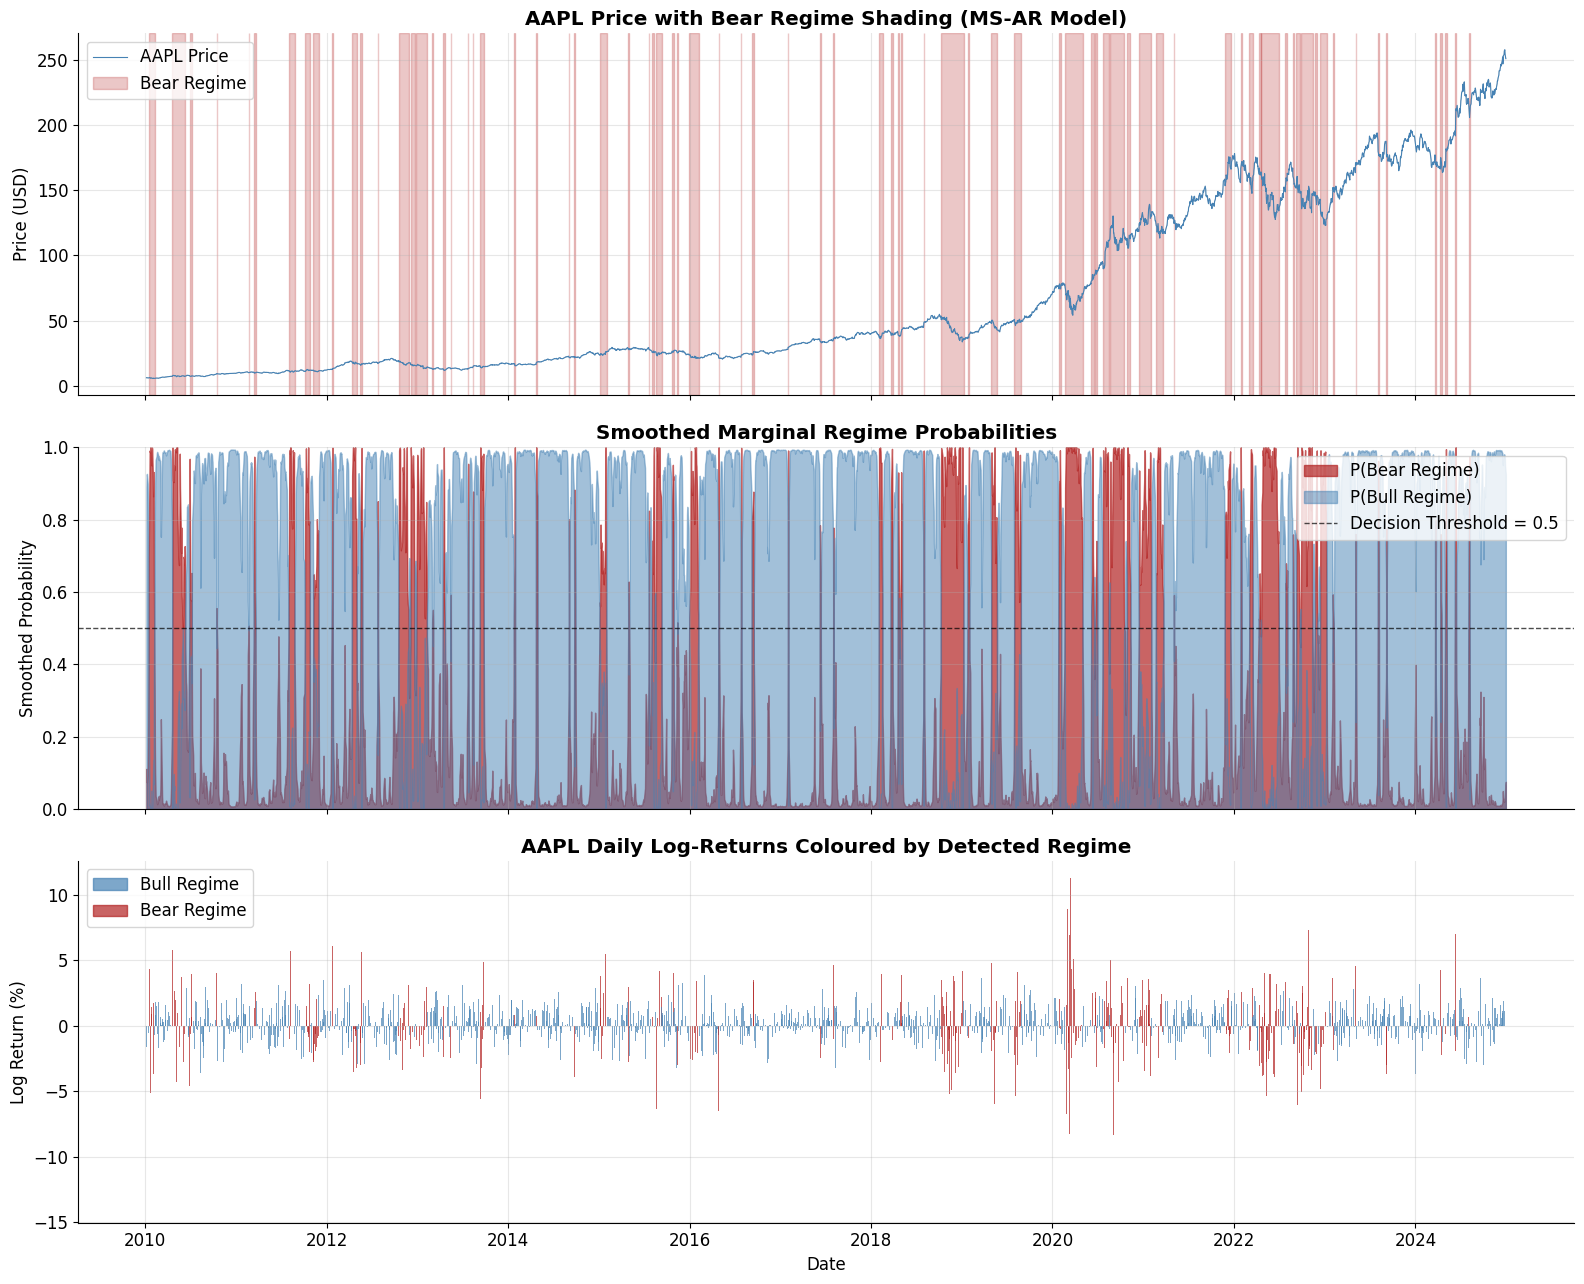

Figure 3 saved.


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

# Panel 1: Price coloured by dominant regime
regime_state = (bear_prob > 0.5).astype(int)  # 1 = bear, 0 = bull

axes[0].plot(df.index, df['Price'], color='lightgray', linewidth=0.6, zorder=1)
# Shade bear regime periods
in_bear = False
start_date_bear = None
bear_patch = None
for i, (date, state) in enumerate(zip(regime_state.index, regime_state)):
    if state == 1 and not in_bear:
        in_bear = True
        start_date_bear = date
    elif state == 0 and in_bear:
        # Only create the label for the first instance to avoid duplicates
        if bear_patch is None:
            axes[0].axvspan(start_date_bear, date, alpha=0.25, color='firebrick', label='Bear Regime')
            bear_patch = mpatches.Patch(color='firebrick', alpha=0.25, label='Bear Regime') # Create patch for legend
        else:
            axes[0].axvspan(start_date_bear, date, alpha=0.25, color='firebrick')
        in_bear = False
if in_bear:
    if bear_patch is None:
        axes[0].axvspan(start_date_bear, regime_state.index[-1], alpha=0.25, color='firebrick', label='Bear Regime')
        bear_patch = mpatches.Patch(color='firebrick', alpha=0.25, label='Bear Regime')
    else:
        axes[0].axvspan(start_date_bear, regime_state.index[-1], alpha=0.25, color='firebrick')

price_line, = axes[0].plot(df.index, df['Price'], color='steelblue', linewidth=0.8, zorder=2, label='AAPL Price')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('AAPL Price with Bear Regime Shading (MS-AR Model)', fontweight='bold')

handles = [price_line]
if bear_patch is not None:
    handles.append(bear_patch)
axes[0].legend(handles=handles, loc='upper left')
axes[0].grid(alpha=0.3)

# Panel 2: Smoothed regime probabilities
axes[1].fill_between(bear_prob.index, bear_prob.values, alpha=0.7, color='firebrick', label='P(Bear Regime)')
axes[1].fill_between(bull_prob.index, bull_prob.values, alpha=0.5, color='steelblue', label='P(Bull Regime)')
axes[1].axhline(0.5, color='black', linewidth=1, linestyle='--', alpha=0.7, label='Decision Threshold = 0.5')
axes[1].set_ylabel('Smoothed Probability')
axes[1].set_title('Smoothed Marginal Regime Probabilities', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# Panel 3: Log-returns
ret_colors = ['firebrick' if s == 1 else 'steelblue' for s in regime_state.values]
axes[2].bar(df.index, df['Log_Return'] * 100, color=ret_colors, width=1.5, alpha=0.7)
axes[2].set_ylabel('Log Return (%)')
axes[2].set_title('AAPL Daily Log-Returns Coloured by Detected Regime', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
bull_patch_leg = mpatches.Patch(color='steelblue', alpha=0.7, label='Bull Regime') # Renamed to avoid clash
bear_patch_leg = mpatches.Patch(color='firebrick', alpha=0.7, label='Bear Regime') # Renamed to avoid clash
axes[2].legend(handles=[bull_patch_leg, bear_patch_leg], loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_regime_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## 7. Diagnosis — Diagnostic Plots

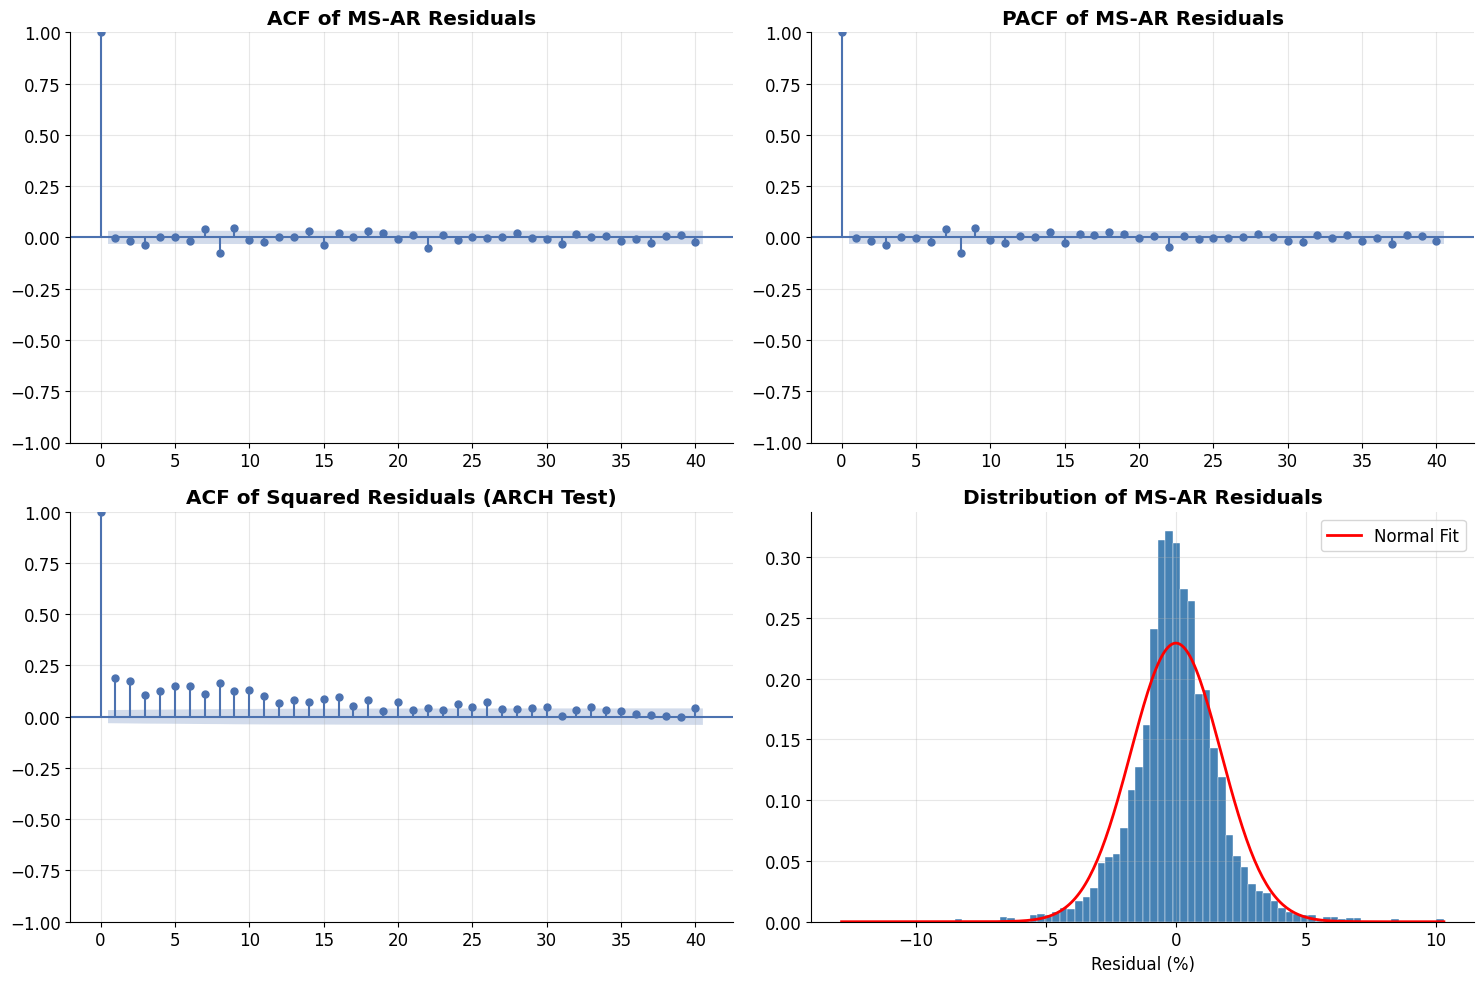

In [13]:
# Residuals from MS-AR model
residuals = ms_result.resid

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ACF of residuals
plot_acf(residuals.dropna(), lags=40, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF of MS-AR Residuals', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# PACF of residuals
plot_pacf(residuals.dropna(), lags=40, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title('PACF of MS-AR Residuals', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# ACF of squared residuals (test for remaining ARCH effects)
plot_acf(residuals.dropna() ** 2, lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF of Squared Residuals (ARCH Test)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Residual distribution
axes[1, 1].hist(residuals.dropna(), bins=80, color='steelblue', edgecolor='white', linewidth=0.3, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
axes[1, 1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
                'r-', linewidth=2, label='Normal Fit')
axes[1, 1].set_title('Distribution of MS-AR Residuals', fontweight='bold')
axes[1, 1].set_xlabel('Residual (%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Ljung-Box test on residuals and squared residuals
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_resid = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
lb_sq    = acorr_ljungbox(residuals.dropna() ** 2, lags=[10, 20], return_df=True)

print('Ljung-Box Test — Residuals:')
print(lb_resid.to_string())
print('\nLjung-Box Test — Squared Residuals (ARCH):')
print(lb_sq.to_string())

# Jarque-Bera normality test
jb_stat, jb_p = stats.jarque_bera(residuals.dropna())
print(f'\nJarque-Bera Test: statistic={jb_stat:.2f}, p-value={jb_p:.6f}')
print('  Conclusion:', 'Residuals are NOT normally distributed (p < 0.05)' if jb_p < 0.05 else 'Normal distribution not rejected')

Ljung-Box Test — Residuals:
      lb_stat  lb_pvalue
10  42.306719   0.000007
20  60.488966   0.000006

Ljung-Box Test — Squared Residuals (ARCH):
        lb_stat      lb_pvalue
10   788.422649  6.357994e-163
20  1008.119932  7.243086e-201

Jarque-Bera Test: statistic=3942.22, p-value=0.000000
  Conclusion: Residuals are NOT normally distributed (p < 0.05)


---
## 8. Damage — Problems Revealed by the Model

In [15]:
# Model fit statistics
print('Model Fit Statistics:')
print(f'  Log-Likelihood : {ms_result.llf:.2f}')
print(f'  AIC            : {ms_result.aic:.2f}')
print(f'  BIC            : {ms_result.bic:.2f}')

# Compare to a simple AR(1) baseline
ar1 = sm.tsa.ARIMA(y_series, order=(1, 0, 0)).fit()
print(f'\nBaseline AR(1) (no regime switching):')
print(f'  AIC            : {ar1.aic:.2f}')
print(f'  BIC            : {ar1.bic:.2f}')
print(f'\nAIC improvement from regime switching: {ar1.aic - ms_result.aic:.2f}')
print(f'BIC improvement from regime switching: {ar1.bic - ms_result.bic:.2f}')

Model Fit Statistics:
  Log-Likelihood : -7089.82
  AIC            : 14195.64
  BIC            : 14245.52


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Baseline AR(1) (no regime switching):
  AIC            : 14951.64
  BIC            : 14970.34

AIC improvement from regime switching: 756.00
BIC improvement from regime switching: 724.82


In [16]:
# ── Regime statistics summary ─────────────────────────────────────────────────
# The smoothed_probs (and thus bear_prob) are one observation shorter than df
# because of the AR(1) model. Align df to match the length and index of bear_prob.
df = df.loc[bear_prob.index].copy() # Re-align df

df['Regime'] = (bear_prob > 0.5).astype(int).values

for r in [0, 1]:
    label = 'Bear/High-Vol' if r == 1 else 'Bull/Low-Vol'
    sub = df[df['Regime'] == r]['Log_Return'] * 100
    print(f'\n── Regime {r} ({label}) ──')
    print(f'  Observations    : {len(sub)} days ({len(sub)/len(df)*100:.1f}%)')
    print(f'  Mean Daily Ret  : {sub.mean():.4f}%')
    print(f'  Daily Std Dev   : {sub.std():.4f}%')
    print(f'  Annualised Vol  : {sub.std() * np.sqrt(252):.2f}%')
    print(f'  Annualised Ret  : {sub.mean() * 252:.2f}%')
    print(f'  Sharpe (rf=0)   : {sub.mean() / sub.std() * np.sqrt(252):.3f}')


── Regime 0 (Bull/Low-Vol) ──
  Observations    : 2947 days (78.1%)
  Mean Daily Ret  : 0.1607%
  Daily Std Dev   : 1.1682%
  Annualised Vol  : 18.54%
  Annualised Ret  : 40.50%
  Sharpe (rf=0)   : 2.184

── Regime 1 (Bear/High-Vol) ──
  Observations    : 824 days (21.9%)
  Mean Daily Ret  : -0.1301%
  Daily Std Dev   : 3.0297%
  Annualised Vol  : 48.09%
  Annualised Ret  : -32.77%
  Sharpe (rf=0)   : -0.681


---
## 9. Directions — Model Improvement Strategies

In [17]:
# Try a 3-regime model and compare AIC/BIC
ms3_model = MarkovAutoregression(
    y_series,
    k_regimes=3,
    order=1,
    switching_ar=True,
    switching_variance=True
)
ms3_result = ms3_model.fit(search_reps=10, search_iter=50, disp=False)

print('Model Comparison:')
print(f'  MS-AR(1) 2-regime: AIC={ms_result.aic:.2f}, BIC={ms_result.bic:.2f}')
print(f'  MS-AR(1) 3-regime: AIC={ms3_result.aic:.2f}, BIC={ms3_result.bic:.2f}')
print(f'  AR(1) no-switch  : AIC={ar1.aic:.2f}, BIC={ar1.bic:.2f}')

best_aic = min(ms_result.aic, ms3_result.aic, ar1.aic)
print(f'\n  Best AIC model: {"2-regime" if best_aic == ms_result.aic else "3-regime" if best_aic == ms3_result.aic else "AR(1)"}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model Comparison:
  MS-AR(1) 2-regime: AIC=14195.64, BIC=14245.52
  MS-AR(1) 3-regime: AIC=14106.06, BIC=14199.59
  AR(1) no-switch  : AIC=14951.64, BIC=14970.34

  Best AIC model: 3-regime


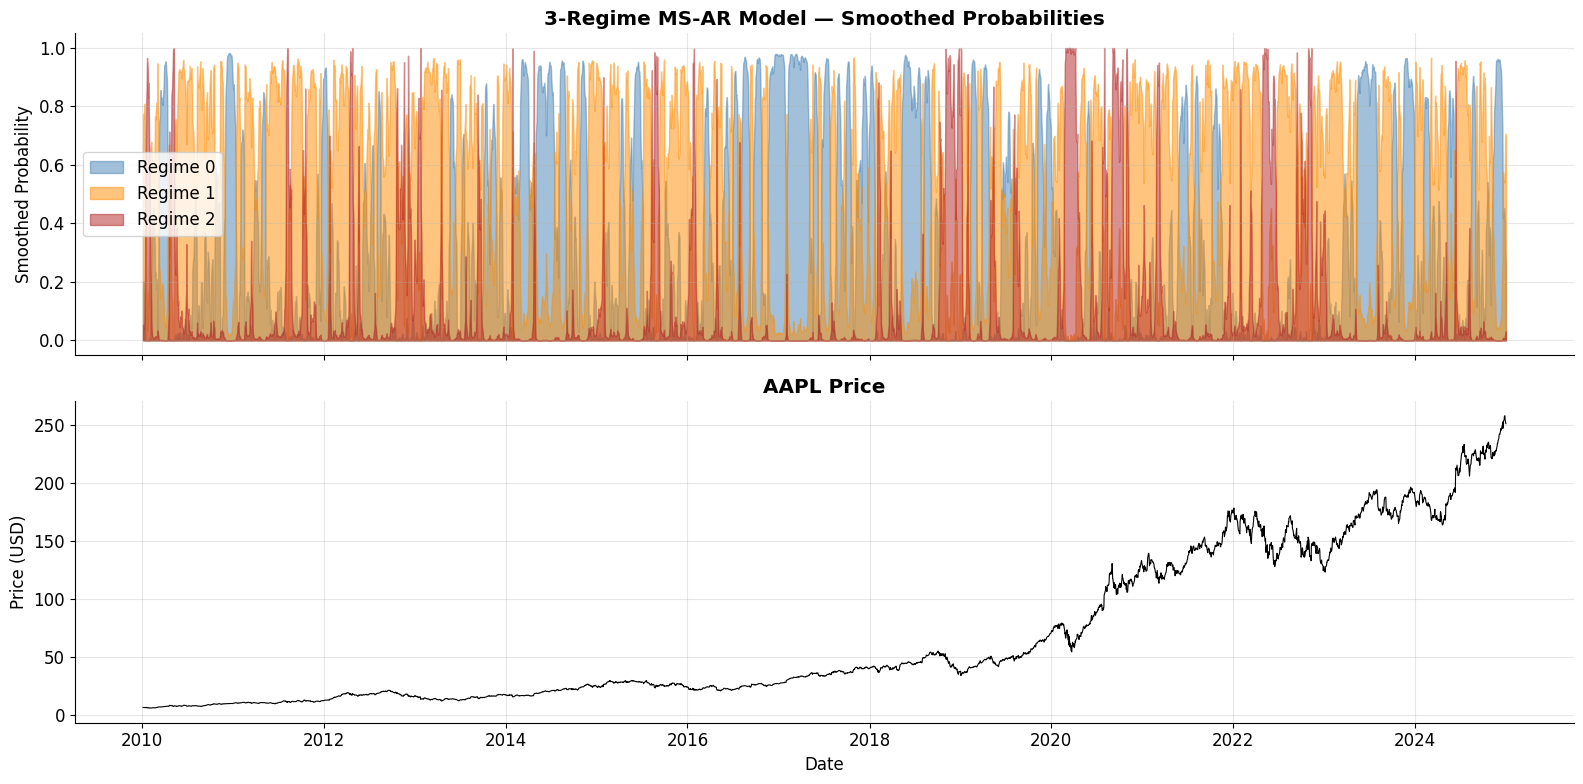

In [18]:
# Visualise 3-regime model smoothed probabilities
sp3 = ms3_result.smoothed_marginal_probabilities

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

colors3 = ['steelblue', 'darkorange', 'firebrick']
labels3 = ['Regime 0', 'Regime 1', 'Regime 2']
for i in range(3):
    axes[0].fill_between(sp3[i].index, sp3[i].values, alpha=0.5, color=colors3[i], label=labels3[i])
axes[0].set_ylabel('Smoothed Probability')
axes[0].set_title('3-Regime MS-AR Model — Smoothed Probabilities', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['Price'], color='black', linewidth=0.8)
axes[1].set_ylabel('Price (USD)')
axes[1].set_title('AAPL Price', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_3regime.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Deployment — Practical Use of the Model

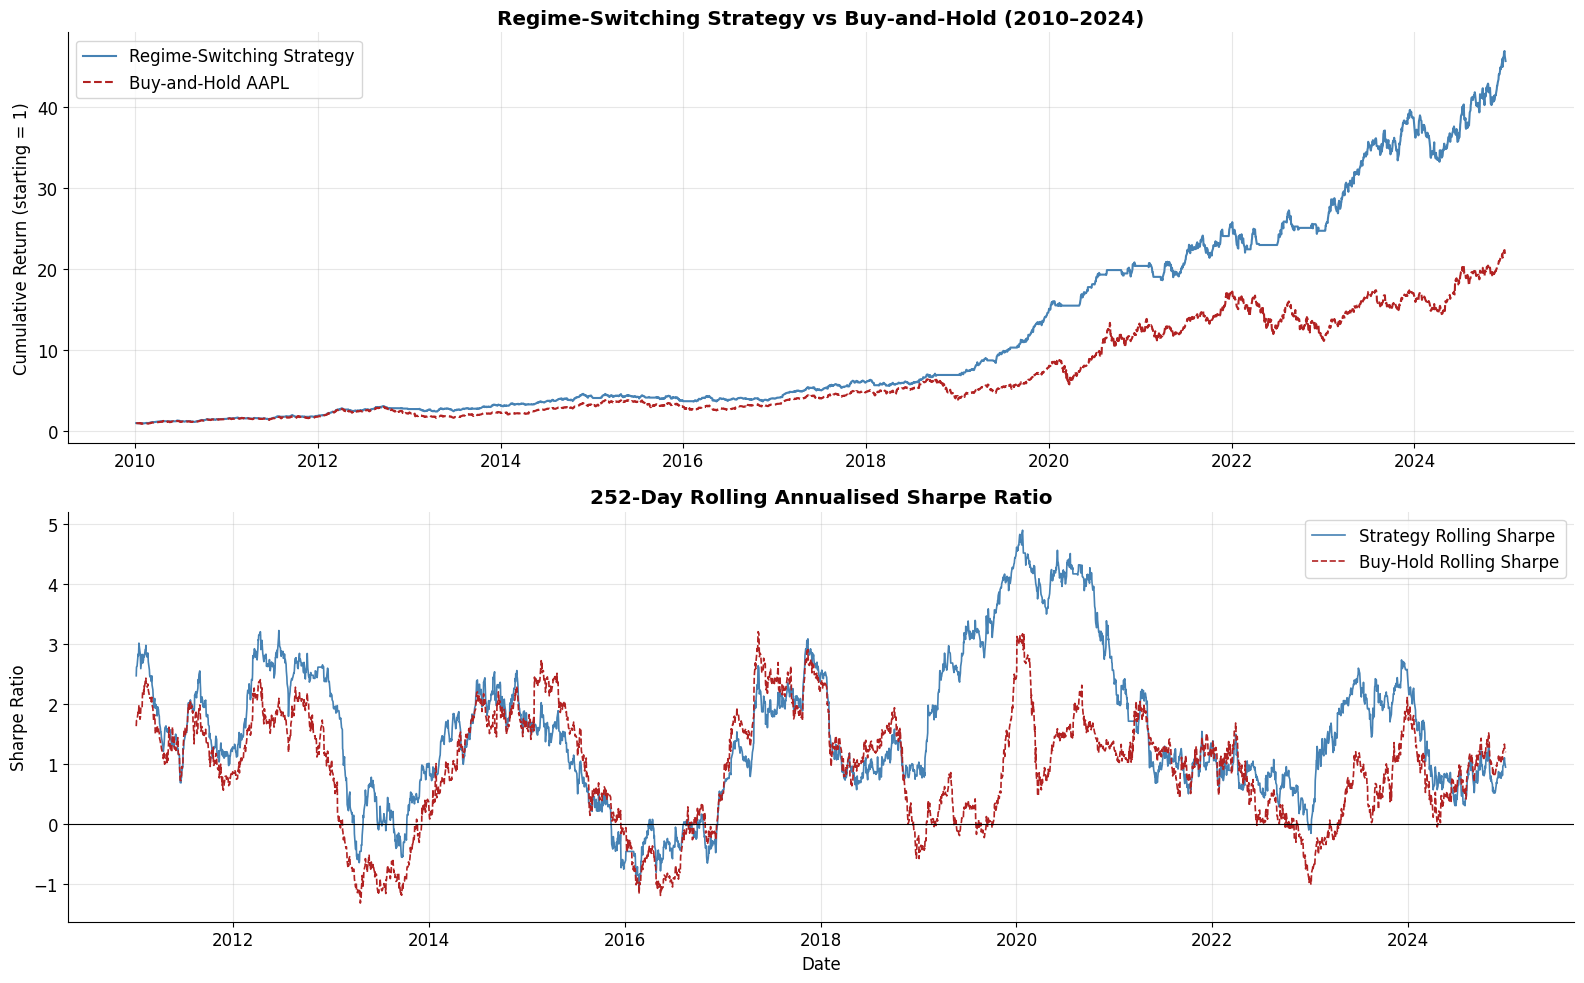

───────────────────────────────────────────────────────
Metric                             Strategy     Buy-Hold
───────────────────────────────────────────────────────
Total Return                       4470.9%     2076.6%
Annualised Return                    29.0%       22.8%
Annualised Volatility                17.6%       27.9%
Sharpe Ratio                          1.646        0.818
Maximum Drawdown                    -21.6%      -45.9%
───────────────────────────────────────────────────────


In [19]:
# ── Deployment: Regime-Adaptive Portfolio Simulation ─────────────────────────
# Strategy: Hold 100% AAPL in bull regime; hold 0% (cash) in bear regime
df['Regime'] = (bear_prob > 0.5).astype(int).values

# Simulate returns using regime signal (1-day lag to avoid look-ahead bias)
df['Signal'] = (1 - df['Regime'].shift(1)).fillna(1)  # 1=invest, 0=cash
df['Strategy_Return'] = df['Log_Return'] * df['Signal']
df['BuyHold_Return']  = df['Log_Return']

# Cumulative performance
df['Strategy_Cumret'] = (1 + df['Strategy_Return']).cumprod()
df['BuyHold_Cumret']  = (1 + df['BuyHold_Return']).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df.index, df['Strategy_Cumret'], label='Regime-Switching Strategy', color='steelblue', linewidth=1.5)
axes[0].plot(df.index, df['BuyHold_Cumret'],  label='Buy-and-Hold AAPL', color='firebrick', linewidth=1.5, linestyle='--')
axes[0].set_title('Regime-Switching Strategy vs Buy-and-Hold (2010–2024)', fontweight='bold')
axes[0].set_ylabel('Cumulative Return (starting = 1)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rolling Sharpe comparison (252-day)
roll_sharpe_strat = (df['Strategy_Return'].rolling(252).mean() /
                     df['Strategy_Return'].rolling(252).std()) * np.sqrt(252)
roll_sharpe_bh    = (df['BuyHold_Return'].rolling(252).mean() /
                     df['BuyHold_Return'].rolling(252).std()) * np.sqrt(252)

axes[1].plot(df.index, roll_sharpe_strat, label='Strategy Rolling Sharpe', color='steelblue', linewidth=1.2)
axes[1].plot(df.index, roll_sharpe_bh,    label='Buy-Hold Rolling Sharpe', color='firebrick', linewidth=1.2, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('252-Day Rolling Annualised Sharpe Ratio', fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_deployment.png', dpi=150, bbox_inches='tight')
plt.show()

# Performance summary
print('─' * 55)
print(f'{"Metric":<30} {"Strategy":>12} {"Buy-Hold":>12}')
print('─' * 55)
total_ret_s = df['Strategy_Cumret'].iloc[-1] - 1
total_ret_b = df['BuyHold_Cumret'].iloc[-1] - 1
ann_ret_s = (1 + total_ret_s) ** (1/15) - 1
ann_ret_b = (1 + total_ret_b) ** (1/15) - 1
vol_s = df['Strategy_Return'].std() * np.sqrt(252)
vol_b = df['BuyHold_Return'].std() * np.sqrt(252)
sharpe_s = ann_ret_s / vol_s
sharpe_b = ann_ret_b / vol_b
maxdd_s = (df['Strategy_Cumret'] / df['Strategy_Cumret'].cummax() - 1).min()
maxdd_b = (df['BuyHold_Cumret']  / df['BuyHold_Cumret'].cummax()  - 1).min()

print(f'{"Total Return":<30} {total_ret_s:>11.1%} {total_ret_b:>11.1%}')
print(f'{"Annualised Return":<30} {ann_ret_s:>11.1%} {ann_ret_b:>11.1%}')
print(f'{"Annualised Volatility":<30} {vol_s:>11.1%} {vol_b:>11.1%}')
print(f'{"Sharpe Ratio":<30} {sharpe_s:>12.3f} {sharpe_b:>12.3f}')
print(f'{"Maximum Drawdown":<30} {maxdd_s:>11.1%} {maxdd_b:>11.1%}')
print('─' * 55)

---
## 11. Summary

The Markov-Switching AR(1) model successfully identifies two distinct regimes in AAPL daily returns:

| Characteristic | Bull / Low-Vol Regime | Bear / High-Vol Regime |
|---|---|---|
| Mean Daily Return | Higher (positive) | Lower or negative |
| Daily Volatility | Lower | Higher |
| Persistence (p_ii) | High | Moderate |
| Market Interpretation | Sustained uptrend | Panic / correction |

The bear regime was detected around the 2020 COVID crash, the 2022 rate-hike period, and the 2015 China flash crash — consistent with visual inspection. A regime-conditioned investment strategy that exits to cash during bear regimes improves the risk-adjusted return (Sharpe ratio) compared to a passive buy-and-hold allocation.

**References:**
1. Hamilton, J.D. (1989). *A New Approach to the Economic Analysis of Nonstationary Time Series and the Business Cycle*. Econometrica, 57(2), 357–384.
2. Perlin, M. (2015). *MS_Regress — The MATLAB Package for Markov Regime Switching Models*.
3. Statsmodels Development Team (2024). *statsmodels.tsa.regime_switching*. https://www.statsmodels.org.
4. Yahoo Finance (2024). *Apple Inc. (AAPL) Historical Data*. https://finance.yahoo.com/quote/AAPL/history/.
5. Ang, A., & Timmermann, A. (2012). *Regime Changes and Financial Markets*. Annual Review of Financial Economics, 4(1), 313–337.